In [2]:
import sys
import gc
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from scipy import ndimage as ndi
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import dilation, disk
from skimage.segmentation import watershed

REPO_ROOT = Path('').resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.helpers import load_config, get_pixel_size
from utils.logger import DeepAxonLogger
from morphometrics.morphometrics import get_morphometrics
from scipy.spatial import cKDTree


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [3]:
threshold = 0.17
disk_r    = 5

In [4]:
def get_labels_axons(img: np.ndarray) -> np.ndarray:
    """
    Watershed segmentation using V3 threshold-based seeding.

    Foreground seeds: distance > threshold * distance.max()
      Low threshold intentional — maximizes seed count to separate
      closely packed axons. V3 validated value.
      Configurable via config.json: watershed.distance_threshold

    Background marker: dilation of mask with disk(radius)
      Configurable via config.json: watershed.dilation_disk
    """

    distance     = ndi.distance_transform_edt(img)
    sure_fg_mask = distance > threshold * distance.max()
    markers      = label(sure_fg_mask)
    sure_bg_mask = dilation(img, disk(disk_r))
    markers[sure_bg_mask == 0] = markers.max() + 1
    segmented = watershed(-distance, markers, mask=img)
    del distance, sure_fg_mask, sure_bg_mask, markers
    return segmented
  
def get_labels_fiber(
    fiber_mask: np.ndarray,
    axon_label: np.ndarray,
) -> np.ndarray:
    """
    Watershed segmentation of fiber_mask seeded from axon labels.

    Instead of deriving markers from fiber_mask's own distance transform
    (which fails when myelin sheaths touch), we transfer one seed per
    axon region from the already-labelled axon_mask.

    Foreground seeds: distance-transform peak of each axon region,
      guaranteed to land interior to the corresponding fiber region
      since axon ⊂ fiber geometrically.

    Background marker: dilation of fiber_mask with disk(5) — same
      logic as original get_labels().
    """
    disk_r = 5

    # ── 1. Extract one seed per axon at its distance-transform peak ──────────
    # Using distance peak (not centroid) so seed is maximally interior —
    # centroid can fall outside non-convex shapes
    axon_distance = ndi.distance_transform_edt(axon_label > 0)
    markers       = np.zeros_like(fiber_mask, dtype=int)

    for region in regionprops(axon_label):
        region_dist = np.where(axon_label == region.label, axon_distance, 0)
        peak        = np.unravel_index(np.argmax(region_dist), region_dist.shape)
        markers[peak] = region.label

    # ── 2. Snap any seeds that fall outside fiber_mask to nearest fg pixel ───
    # Shouldn't happen (axon ⊂ fiber) but guards against mask misalignment
    lost = (markers > 0) & (fiber_mask == 0)
    if np.any(lost):
        fg_coords   = np.array(np.where(fiber_mask > 0)).T
        lost_coords = np.array(np.where(lost)).T
        tree        = cKDTree(fg_coords)
        for coord in lost_coords:
            _, idx  = tree.query(coord)
            nearest = tuple(fg_coords[idx])
            markers[nearest]     = markers[tuple(coord)]
            markers[tuple(coord)] = 0

    # ── 3. Background marker — same as original get_labels() ─────────────────
    sure_bg              = dilation(fiber_mask, disk(disk_r))
    markers[sure_bg == 0] = markers.max() + 1

    # ── 4. Watershed on fiber_mask ────────────────────────────────────────────
    fiber_distance = ndi.distance_transform_edt(fiber_mask)
    segmented      = watershed(-fiber_distance, markers, mask=fiber_mask)

    del axon_distance, fiber_distance, sure_bg, markers
    return segmented

In [5]:
# ─── Matching helpers ─────────────────────────────────────────────────────────

def get_axon_row(axon_df: pd.DataFrame, left, right, top, bottom) -> pd.DataFrame:
    """Find the largest axon whose centroid falls within the fiber bounding box."""
    left, right, top, bottom = int(left), int(right), int(top), int(bottom)
    axons_in_box = axon_df[
        (axon_df['centroid-0'] >= left) & (axon_df['centroid-0'] <= right) &
        (axon_df['centroid-1'] >= top)  & (axon_df['centroid-1'] <= bottom)
    ]
    if axons_in_box.empty:
        return axons_in_box
    return axons_in_box[axons_in_box['area'] == axons_in_box['area'].max()]


# ─── Main analysis ────────────────────────────────────────────────────────────

def get_morphometrics(
    seg_path: str,
    mag: str,
    log: DeepAxonLogger
) -> pd.DataFrame:
    """
    Extract morphometric measurements from a single segmented BGW image.

    Args:
        seg_path: path to segmented .tif (BGW: black=background, grey=myelin, white=axon)
        mag:      magnification string e.g. '40X'
        log:      logger instance

    Returns:
        DataFrame of per-axon measurements, or None on failure.
    """
    img = cv2.imread(seg_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        log.error(f"Could not read: {seg_path}")
        return None

    h, w = img.shape
    px_size = get_pixel_size(mag, w)
    if px_size is None:
        log.warn(f"No pixel size for {mag} at width {w}px — outputting pixel units only")

    # ── Extract masks from BGW image ─────────────────────────────────────────
    # BGW contract: white(255)=axon, grey(128)=myelin
    # See segment/segment.py recolor() — this mapping must stay in sync.
    axon_mask  = cv2.inRange(img, 200, 255)  # white = axon
    fiber_mask = cv2.inRange(img, 1, 255)    # all non-black = axon + myelin

    if not np.any(axon_mask):
        log.warn(f"No axons detected in {Path(seg_path).name}")
        return pd.DataFrame()

    # Watershed both masks using V3 get_labels
    axon_label  = get_labels_axons(axon_mask.astype(bool))
    fiber_label = get_labels_fiber(fiber_mask.astype(bool), axon_label)

    # regionprops_table on full label arrays — memory efficient
    axon_props = regionprops_table(axon_label, properties=(
        'label', 'centroid', 'area',
        'axis_minor_length', 'axis_major_length',
        'eccentricity', 'orientation', 'perimeter', 'solidity'
    ))
    fiber_props = regionprops_table(fiber_label, properties=(
        'label', 'bbox', 'area',
        'axis_minor_length', 'axis_major_length',
        'eccentricity', 'orientation', 'perimeter'
    ))

    axon_df  = pd.DataFrame.from_dict(axon_props)
    fiber_df = pd.DataFrame.from_dict(fiber_props)

    # del axon_label, fiber_label, axon_mask, fiber_mask, img
    gc.collect()

    if axon_df.empty or fiber_df.empty:
        log.warn(f"No regions found in {Path(seg_path).name}")
        return pd.DataFrame()

    # ── Myelin-first matching loop (V3 active loop) ───────────────────────────
    rows = []
    assigned_axon_labels = set()  # Tracks matched axons — prevents one axon being assigned to multiple fibers

    for _, row in fiber_df.iterrows():
        left   = row['bbox-0']
        right  = row['bbox-2']
        top    = row['bbox-1']
        bottom = row['bbox-3']

        axon_row = get_axon_row(axon_df, left, right, top, bottom)
        if axon_row.empty:
            continue

        # Skip if this axon has already been matched to a different fiber
        axon_label_id = int(axon_row['label'].iloc[0])
        if axon_label_id in assigned_axon_labels:
            continue
        assigned_axon_labels.add(axon_label_id)

        # ── Axon morphology ───────────────────────────────────────────────
        axon_area         = float(axon_row['area'].iloc[0])
        axon_perimeter    = float(axon_row['perimeter'].iloc[0])
        axon_major        = float(axon_row['axis_major_length'].iloc[0])
        axon_minor        = float(axon_row['axis_minor_length'].iloc[0])
        axon_eccentricity = float(axon_row['eccentricity'].iloc[0])
        axon_orientation  = float(axon_row['orientation'].iloc[0])
        axon_solidity     = float(axon_row['solidity'].iloc[0])
        x                 = float(axon_row['centroid-0'].iloc[0])
        y                 = float(axon_row['centroid-1'].iloc[0])

        # Area-based equivalent circle diameter (V3)
        axon_equiv_diam  = np.sqrt(4 * axon_area / np.pi)
        axon_deformation = axon_major / axon_equiv_diam if axon_equiv_diam > 0 else np.nan

        # ── Fiber / Myelin morphology ─────────────────────────────────────
        fiber_area         = float(row['area'])
        fiber_major        = float(row['axis_major_length'])
        fiber_minor        = float(row['axis_minor_length'])
        fiber_perimeter    = float(row['perimeter'])
        fiber_eccentricity = float(row['eccentricity'])
        fiber_orientation  = float(row['orientation'])

        fiber_equiv_diam  = np.sqrt(fiber_area / np.pi) * 2
        fiber_deformation = fiber_major / fiber_minor if fiber_minor > 0 else np.nan

        myelin_area      = fiber_area - axon_area

        # V3 formula: uses fiber equiv diameter and axon major axis.
        # Intentional mix of shape measures — V3 validated.
        # Alternative: (fiber_equiv_diam - axon_equiv_diam) / 2 for
        # fully area-based calculation.
        myelin_thickness = (fiber_equiv_diam - axon_major) / 2

        # ── Derived: three g-ratio measures ──────────────────────────────
        # gratio_area: equiv circle diam ratio (area-based)
        gratio_area = axon_equiv_diam / fiber_equiv_diam if fiber_equiv_diam > 0 else np.nan

        # gratio_axes: mean of major+minor axes ratio
        axon_mean_axis  = (axon_major + axon_minor) / 2
        fiber_mean_axis = (fiber_major + fiber_minor) / 2
        gratio_axes     = axon_mean_axis / fiber_mean_axis if fiber_mean_axis > 0 else np.nan

        # gratio: average of both — primary output column
        if np.isnan(gratio_area) or np.isnan(gratio_axes):
            continue
        gratio = (gratio_area + gratio_axes) / 2

        # Filter: discard if ANY gratio is outside (0, 1) — physically impossible
        if not (0 < gratio_area < 1 and 0 < gratio_axes < 1 and 0 < gratio < 1):
            continue

        new_row = {
            # Identification
            'label': int(row['label']),
            'x':     round(x, 1),
            'y':     round(y, 1),

            # Axon morphometrics (pixel units)
            'axon_area':         round(axon_area, 2),
            'axon_perimeter':    round(axon_perimeter, 3),
            'axon_diam':         round(axon_equiv_diam, 3),
            'axon_major':        round(axon_major, 3),
            'axon_minor':        round(axon_minor, 3),
            'axon_solidity':     round(axon_solidity, 4),
            'axon_deformation':  round(axon_deformation, 4) if not np.isnan(axon_deformation) else np.nan,
            'axon_eccentricity': round(axon_eccentricity, 4),
            'axon_orientation':  round(axon_orientation, 4),

            # Myelin / Fiber morphometrics (pixel units)
            'myelin_area':        round(myelin_area, 2),
            'myelin_thickness':   round(myelin_thickness, 3),
            'myelin_perimeter':   round(fiber_perimeter, 3),
            'fiber_area':         round(fiber_area, 2),
            'fiber_equiv_diam':   round(fiber_equiv_diam, 3),
            'fiber_major':        round(fiber_major, 3),
            'fiber_minor':        round(fiber_minor, 3),
            'fiber_deformation':  round(fiber_deformation, 4) if not np.isnan(fiber_deformation) else np.nan,
            'fiber_eccentricity': round(fiber_eccentricity, 4),
            'fiber_orientation':  round(fiber_orientation, 4),

            # G-ratios
            'gratio_area': round(gratio_area, 4),  # equiv circle diam / equiv circle diam
            'gratio_axes': round(gratio_axes, 4),  # mean(axon axes) / mean(fiber axes)
            'gratio':      round(gratio, 4),        # average of gratio_area and gratio_axes
        }

        # Physical units — only appended if pixel size is calibrated for this mag
        if px_size is not None:
            new_row['axon_area_um2']       = round(axon_area        * px_size ** 2, 3)
            new_row['myelin_area_um2']     = round(myelin_area      * px_size ** 2, 3)
            new_row['fiber_area_um2']      = round(fiber_area       * px_size ** 2, 3)
            new_row['axon_diam_um']        = round(axon_equiv_diam  * px_size, 3)
            new_row['axon_major_um']       = round(axon_major       * px_size, 3)
            new_row['axon_minor_um']       = round(axon_minor       * px_size, 3)
            new_row['fiber_equiv_diam_um'] = round(fiber_equiv_diam * px_size, 3)
            new_row['fiber_major_um']      = round(fiber_major      * px_size, 3)
            new_row['fiber_minor_um']      = round(fiber_minor      * px_size, 3)
            new_row['myelin_thickness_um'] = round(myelin_thickness * px_size, 3)

        rows.append(new_row)

    del axon_df, fiber_df
    gc.collect()

    if not rows:
        log.warn(f"No valid axon-fiber pairs in {Path(seg_path).name}")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df.insert(0, 'image', Path(seg_path).stem)
    df.insert(1, 'resolution', f"{w}x{h}")
    df.insert(2, 'magnification', mag)

    return df, axon_label, fiber_label


# ─── Save output ──────────────────────────────────────────────────────────────

def save_morphometrics(df: pd.DataFrame, output_dir: str, stem: str) -> str:
    """Save morphometrics DataFrame to Excel. Returns output path."""
    config = load_config()
    suffix = config.get("morphometrics_suffix", "_morphometrics")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / f"{stem}{suffix}.xlsx"
    df.to_excel(str(out_path), index=False)
    return str(out_path)

In [6]:
def make_random_cmap(n_labels: int, seed: int = 42) -> mcolors.ListedColormap:
    """Randomized colormap. Label 0 (background) always black."""
    rng    = np.random.default_rng(seed)
    colors = rng.random((max(n_labels + 1, 2), 3))
    colors[0] = [0, 0, 0]  # background = black
    return mcolors.ListedColormap(colors)

In [7]:
test_img = r"T:\Orthopaedics\Lab Imaging Data\plamothe\Colorado Study\100x Images\P1501\P1501_RMND\Segmented\P1501_RMND_100X_002_segmented.tif"
img = cv2.imread(test_img, 0)

In [8]:
df, axons, fibers = get_morphometrics(test_img, "40X", DeepAxonLogger(log_path=None, program='check_watershed'))
df

,image,resolution,magnification,label,x,y,axon_area,axon_perimeter,axon_diam,axon_major,...,axon_area_um2,myelin_area_um2,fiber_area_um2,axon_diam_um,axon_major_um,axon_minor_um,fiber_equiv_diam_um,fiber_major_um,fiber_minor_um,myelin_thickness_um
0,P1501_RMND_100X_002_segmented,1280x1024,40X,1,22.9,152.9,1613.0,204.569,45.318,54.723,...,75.955,278.108,354.062,9.834,11.875,9.604,21.232,23.406,20.040,4.679
1,P1501_RMND_100X_002_segmented,1280x1024,40X,2,38.0,329.6,2255.0,238.894,53.583,92.275,...,106.186,283.523,389.709,11.628,20.024,7.312,22.275,30.806,17.049,1.126
2,P1501_RMND_100X_002_segmented,1280x1024,40X,3,55.1,417.5,3648.0,290.167,68.153,122.257,...,171.781,332.590,504.370,14.789,26.530,8.362,25.341,34.687,19.085,-0.594
3,P1501_RMND_100X_002_segmented,1280x1024,40X,4,27.7,697.4,1367.0,196.462,41.720,79.567,...,64.371,201.023,265.394,9.053,17.266,5.688,18.382,24.943,14.894,0.558
4,P1501_RMND_100X_002_segmented,1280x1024,40X,5,2.8,1234.7,104.0,42.971,11.507,18.154,...,4.897,67.761,72.658,2.497,3.939,1.783,9.618,16.180,6.469,2.839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,P1501_RMND_100X_002_segmented,1280x1024,40X,112,960.9,966.0,307.0,85.355,19.771,34.758,...,14.456,84.478,98.934,4.290,7.543,2.754,11.223,14.393,10.570,1.840
95,P1501_RMND_100X_002_segmented,1280x1024,40X,113,995.9,378.6,2106.0,197.539,51.783,71.848,...,99.169,241.096,340.265,11.237,15.591,8.515,20.814,24.827,18.081,2.612
96,P1501_RMND_100X_002_segmented,1280x1024,40X,114,998.9,1228.8,3318.0,233.823,64.997,82.273,...,156.241,235.963,392.204,14.104,17.853,11.671,22.347,29.761,18.009,2.247
97,P1501_RMND_100X_002_segmented,1280x1024,40X,115,1008.5,861.6,392.0,101.190,22.341,33.905,...,18.459,172.252,190.710,4.848,7.357,4.024,15.583,20.137,13.056,4.113


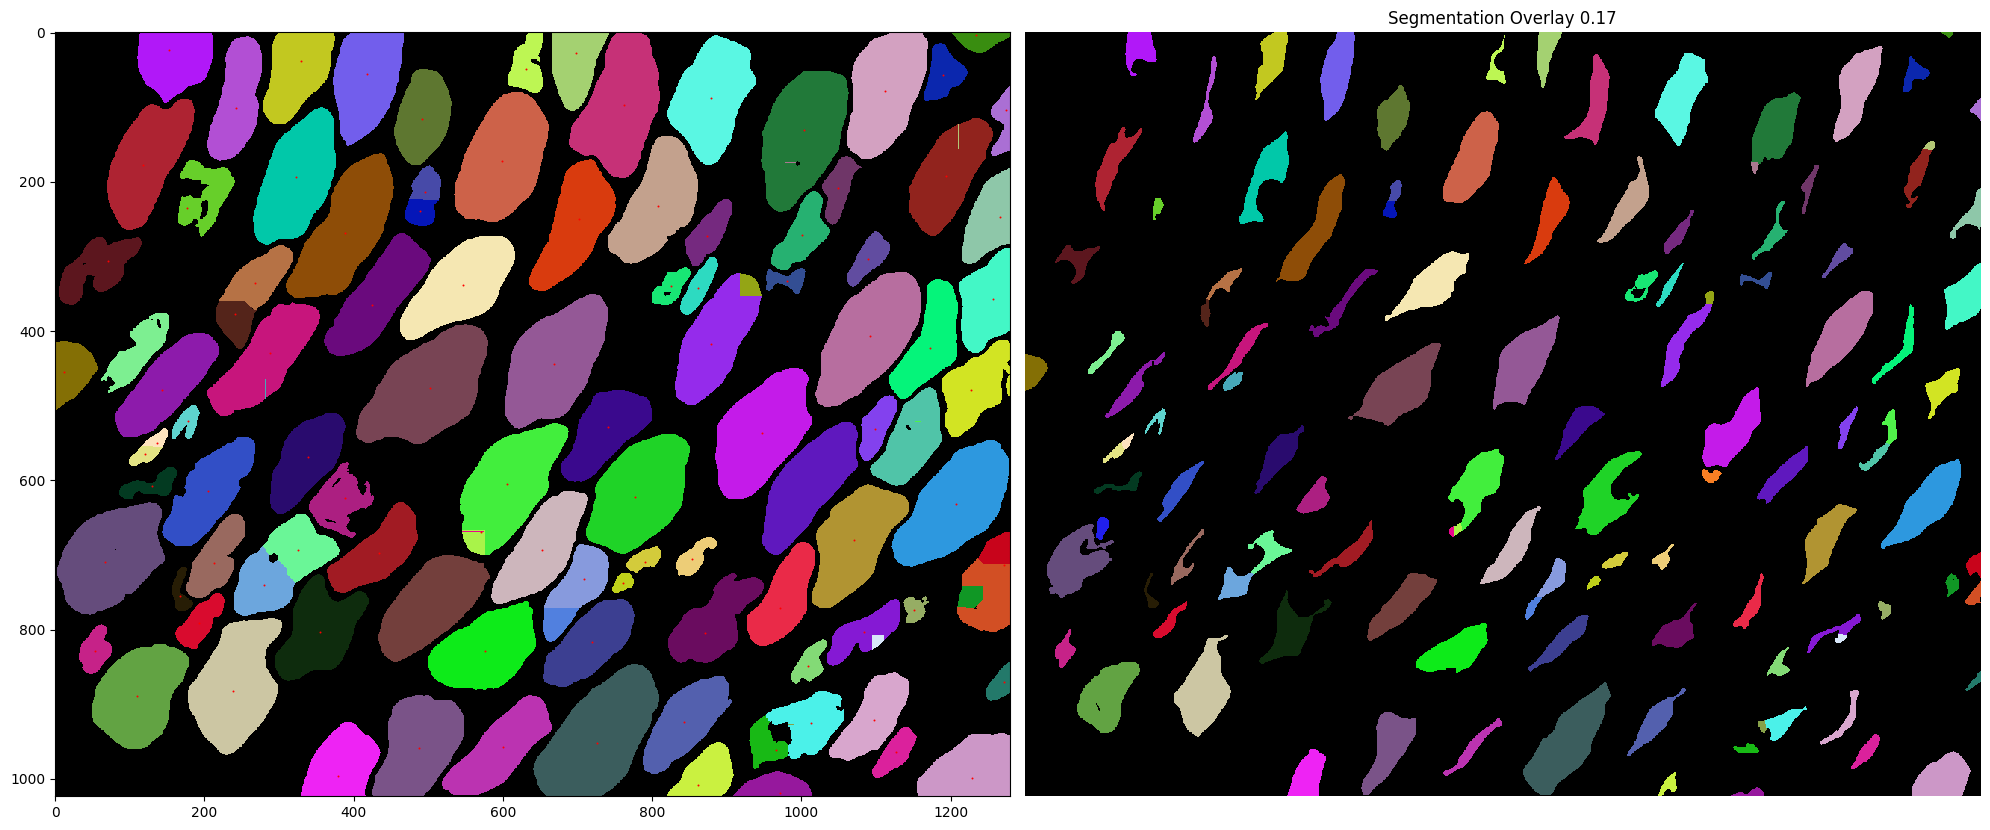

In [9]:
n_axon_labels = axons.max()
n_fiber_labels = fibers.max()

fig, ax = plt.subplots(1, 2, figsize=(20, 10))


ax[0].imshow(fibers, make_random_cmap(n_fiber_labels), interpolation='nearest')

if not df.empty and 'x' in df.columns and 'y' in df.columns:
        ax[0].scatter(
            df['y'].values, df['x'].values,
            s=8, c='red', marker='.', linewidths=0,
            label=f'{len(axons)} matched axons'
        )

ax[1].imshow(axons, make_random_cmap(n_axon_labels), interpolation='nearest')

plt.title('Original Image, alpha=0.4')
plt.title(f"Segmentation Overlay {threshold}")
plt.axis("off")
plt.tight_layout()

plt.show()